### Import Required Libraries

In [3]:
import pandas as pd
import psycopg2

### Connect Python to PostgreSQL

In [ ]:
conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="sql_capstone",
    user="postgres",
    password=""
)

### Load the Clean Dataset

In [5]:
df = pd.read_sql("""
SELECT *
FROM staging.olympics_clean
""", conn)

df.head()

C:\Users\Philemon\AppData\Local\Temp\ipykernel_3548\3204730511.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


,athlete_id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal,decade,age_group,medal_flag
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None,1990,20-24,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None,2010,20-24,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None,1920,20-24,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1900,30+,1
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,None,1980,20-24,0


### Basic Dataset Validation

#### Dataset size

In [6]:
df.shape

(271116, 18)

#### Check missing values

In [7]:
df.isnull().sum()

athlete_id         0
name               0
sex                0
age             9474
height         60171
weight         62875
team               0
noc                0
games              0
year               0
season             0
city               0
sport              0
event              0
medal         231333
decade             0
age_group       9474
medal_flag         0
dtype: int64

#### Check duplicate rows

In [8]:
df.duplicated().sum()

np.int64(1385)

### Validate Analysis 1

#### Decade with Largest Performance Gap

In [9]:
df_medals = df[df['medal'].notna()]

decade_gap = (
    df_medals
    .groupby(['year','sex'])
    .size()
    .reset_index(name='medals')
)

decade_gap['decade'] = (decade_gap['year'] // 10) * 10

decade_summary = (
    decade_gap
    .groupby(['decade','sex'])['medals']
    .sum()
    .unstack()
)

decade_summary['gap'] = abs(decade_summary['M'] - decade_summary['F'])

decade_summary.sort_values('gap', ascending=False).head()

sex,F,M,gap
decade,,,
1920,199.0,2894.0,2695.0
1900,45.0,2334.0,2289.0
1960,702.0,2827.0,2125.0
1980,1650.0,3495.0,1845.0
1970,735.0,2210.0,1475.0


### Validate Analysis 2

#### Medal Efficiency by Gender

In [10]:
gender_stats = df.groupby('sex').agg(
    total_participation=('sex','count'),
    medals_won=('medal', lambda x: x.notna().sum())
)

gender_stats['medal_efficiency'] = (
    gender_stats['medals_won'] / gender_stats['total_participation']
)

gender_stats

,total_participation,medals_won,medal_efficiency
sex,,,
F,74522,11253,0.151002
M,196594,28530,0.145121


In [14]:
df = pd.read_sql("""
SELECT 
    a.*,
    n.region
FROM staging.olympics_clean a
LEFT JOIN analytics.noc_regions n
ON a.noc = n.noc
""", conn)

df.head()

C:\Users\Philemon\AppData\Local\Temp\ipykernel_3548\371374264.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


,athlete_id,name,sex,age,height,weight,team,noc,games,year,season,city,sport,event,medal,decade,age_group,medal_flag,region
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None,1990,20-24,0,Asia
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None,2010,20-24,0,Asia
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None,1920,20-24,0,None
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1900,30+,1,None
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,None,1980,20-24,0,None


### Validate Analysis 3

#### Gender Equity by Country

In [15]:
country_medals = df[df['medal'].notna()]

country_gender = (
    country_medals
    .groupby(['region','sex'])
    .size()
    .reset_index(name='medals')
)

country_table = country_gender.pivot_table(
    index='region',
    columns='sex',
    values='medals',
    fill_value=0
)

country_table['gender_gap'] = abs(country_table['M'] - country_table['F'])

country_table.sort_values('gender_gap').head(10)

sex,F,M,gender_gap
region,,,
Africa,70.0,247.0,177.0
Asia,1255.0,1482.0,227.0
South America,208.0,541.0,333.0
Oceania,604.0,944.0,340.0
North America,2342.0,4757.0,2415.0
Europe,1650.0,6486.0,4836.0


In [16]:
df.columns

Index(['athlete_id', 'name', 'sex', 'age', 'height', 'weight', 'team', 'noc',
       'games', 'year', 'season', 'city', 'sport', 'event', 'medal', 'decade',
       'age_group', 'medal_flag', 'region'],
      dtype='object')

In [17]:
df[['noc','region']].head()

,noc,region
0,CHN,Asia
1,CHN,Asia
2,DEN,None
3,DEN,None
4,NED,None


### Validate Analysis 4

#### Sport-Level Gender Expansion

In [18]:
sport_gender = (
    df.groupby(['sport','sex'])
    .size()
    .reset_index(name='participation')
)

sport_table = sport_gender.pivot_table(
    index='sport',
    columns='sex',
    values='participation',
    fill_value=0
)

sport_table.sort_values('F', ascending=False).head(10)

sex,F,M
sport,,
Athletics,11666.0,26958.0
Swimming,9850.0,13345.0
Gymnastics,9129.0,17578.0
Alpine Skiing,3398.0,5431.0
Cross Country Skiing,3385.0,5748.0
Rowing,2193.0,8402.0
Speed Skating,2081.0,3532.0
Fencing,2000.0,8735.0
Biathlon,1863.0,3030.0


#### Save Results for Visualization

In [19]:
decade_summary.to_csv("C:/data/sql-capstone-project/results/decade_gap.csv")
gender_stats.to_csv("C:/data/sql-capstone-project/results/gender_efficiency.csv")
country_table.to_csv("C:/data/sql-capstone-project/results/country_gender_gap.csv")
sport_table.to_csv("C:/data/sql-capstone-project/results/sport_gender_expansion.csv")

### Basic Visualization in Python

#### Top Sports by Country

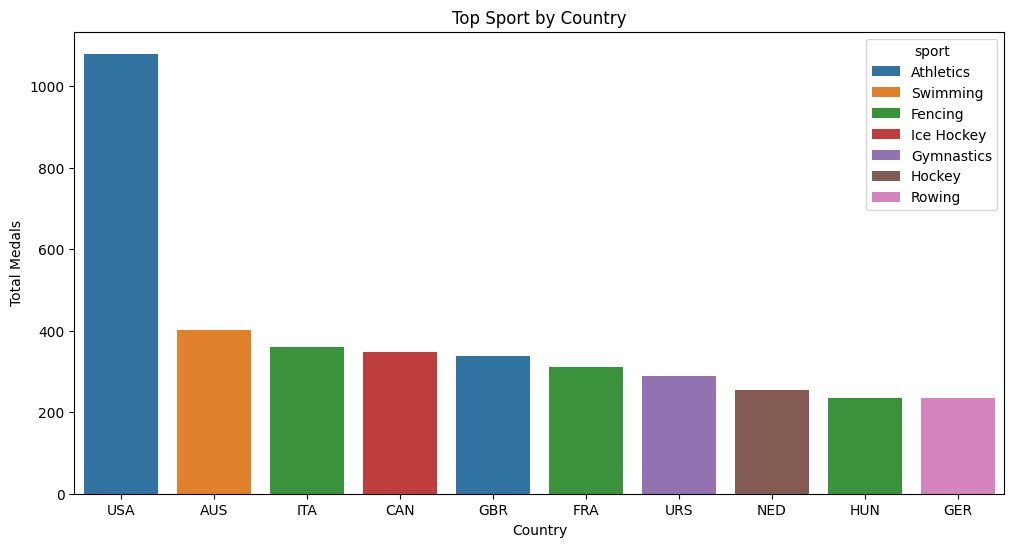

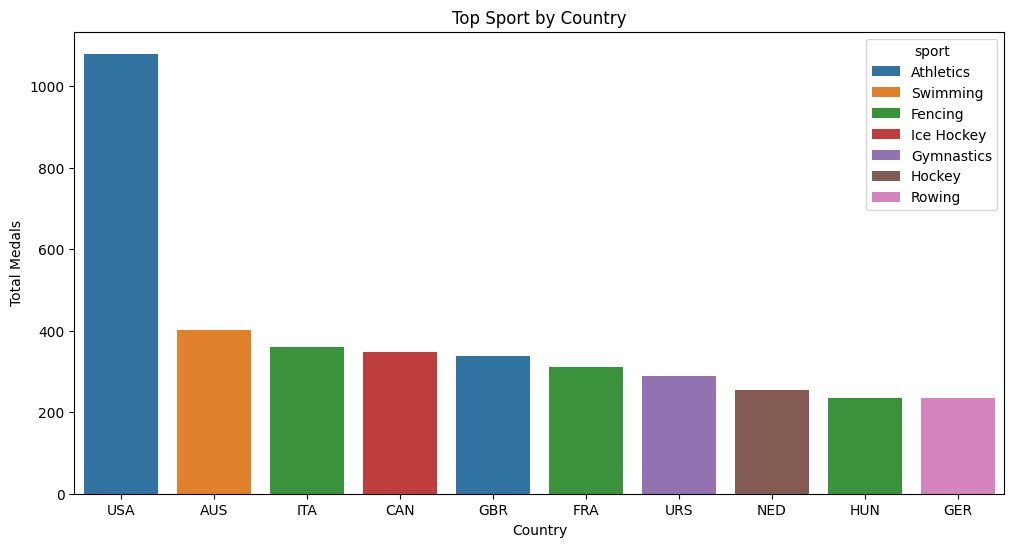

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Filter top sport per country
top_sports = gold_country_sport[gold_country_sport['sport_rank'] == 1]

# Plot top 10 countries by total medals
top10 = top_sports.sort_values(by='total_medals', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x='noc', y='total_medals', hue='sport', data=top10)
plt.title('Top Sport by Country')
plt.ylabel('Total Medals')
plt.xlabel('Country')
plt.show()

In [23]:
import streamlit as st
import pandas as pd
import psycopg2
import plotly.express as px

# --- Database Connection ---
# conn = psycopg2.connect(
#     host="localhost",
#     port=5432,
#     database="sportsstats",
#     user="your_username",
#     password="your_password"
# )

# --- Load Data ---
gold_country_sport = pd.read_sql("SELECT * FROM analytics.gold_country_sport_specialization", conn)
gold_sport_competitive = pd.read_sql("SELECT * FROM analytics.gold_sport_competitiveness", conn)
gold_region_growth = pd.read_sql("SELECT * FROM analytics.gold_region_participation_growth", conn)

# --- Streamlit Layout ---
st.title("Olympic Analytics Dashboard")
st.write("Visualizing 120 Years of Olympic Performance, Participation, and Gender Trends")

# --- Top Country Specializations ---
st.header("Top Sports by Country")
top_sports = gold_country_sport[gold_country_sport['sport_rank']==1].sort_values('total_medals', ascending=False).head(10)
fig1 = px.bar(top_sports, x='noc', y='total_medals', color='sport', title="Top Sport per Country")
st.plotly_chart(fig1)

# --- Sport Competitiveness ---
st.header("Global Sport Competitiveness")
fig2 = px.bar(gold_sport_competitive.sort_values('competitiveness_rank'), 
              x='sport', y='medal_winning_countries', color='competitiveness_rank')
st.plotly_chart(fig2)

# --- Regional Participation Growth ---
st.header("Regional Participation Growth Over Time")
fig3 = px.line(gold_region_growth, x='decade', y='athlete_count', color='region', markers=True)
st.plotly_chart(fig3)

C:\Users\Philemon\AppData\Local\Temp\ipykernel_3548\3414109315.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gold_country_sport = pd.read_sql("SELECT * FROM analytics.gold_country_sport_specialization", conn)
C:\Users\Philemon\AppData\Local\Temp\ipykernel_3548\3414109315.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  gold_sport_competitive = pd.read_sql("SELECT * FROM analytics.gold_sport_competitiveness", conn)
C:\Users\Philemon\AppData\Local\Temp\ipykernel_3548\3414109315.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider usin

2026-03-12 14:10:43.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 14:10:43.468 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 14:10:43.482 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 14:10:43.485 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 14:10:43.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 14:10:43.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 14:10:43.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 14:10:43.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()